In [19]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#K-Means

In [20]:
class KMeans:
    def __init__(self, n_clusters=2, max_iter=300, random_state = 42, shift=1e-4):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.centroids = None
        self.clusters = None
        self.shift = shift

    def _init_centroids(self, X):
        np.random.seed(self.random_state)
        random_k_indices = np.random.choice(X.shape[0], self.n_clusters, replace = False)
        centroids = X[random_k_indices]
        self.centroids = centroids

    def _assign_clusters(self, X):
        # ---
        # distances = None
        # for centroid in self.centroids:
        #     distance = np.sqrt(((X - centroid)**2).sum(axis=1)).reshape(-1,1)
        #     distances = np.hstack([distances, distance]) if distances is not None else distance
        #
        # OR
        #
        # distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        # ---
        # using the 2nd version code
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        self.clusters = np.argmin(distances, axis=1)

    def _update_centroids(self, X):
        new_centroids = []
        for k in range(self.n_clusters):
            centroid = X[self.clusters == k].mean(axis=0)
            new_centroids.append(centroid)
        new_centroids = np.array(new_centroids)
        delta = np.abs(new_centroids - self.centroids)
        self.centroids = new_centroids
        return delta

    def fit(self, X):
        self._init_centroids(X)
        for i in range(self.max_iter):
            self._assign_clusters(X)
            delta = self._update_centroids(X)

            # Check for convergence
            if np.all(delta < self.shift):
                break

            self.display_results(X)

    def predict(self, X):
        # distances = None
        # for centroid in self.centroids:
        #     distance = np.sqrt(((X - centroid)**2).sum(axis=1)).reshape(-1,1)
        #     distances = np.hstack([distances, distance]) if distances is not None else distance
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

    def fit_predict(self, X):
        self.fit(X)
        return self.predict(X)

    def display_results(self, X):
        # Plot the results
        plt.scatter(X[:, 0], X[:, 1], c=self.clusters, s=50, cmap='viridis')
        plt.scatter(self.centroids[:, 0], self.centroids[:, 1], s=200, c='red', marker='X')
        plt.show()


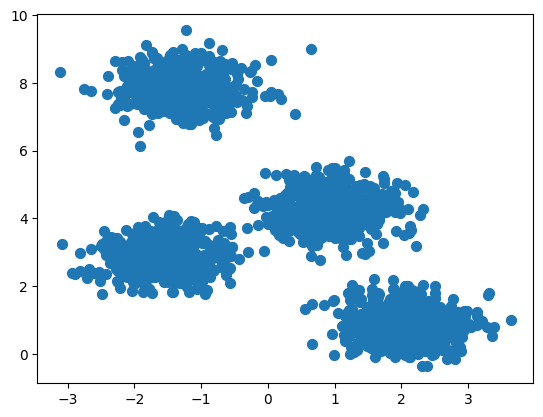

In [21]:
from sklearn.datasets import make_blobs

# Generate synthetic data
X, y =make_blobs(n_samples=2000, centers=4, n_features=2,random_state=0, cluster_std=0.5)
 #make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);
plt.show()

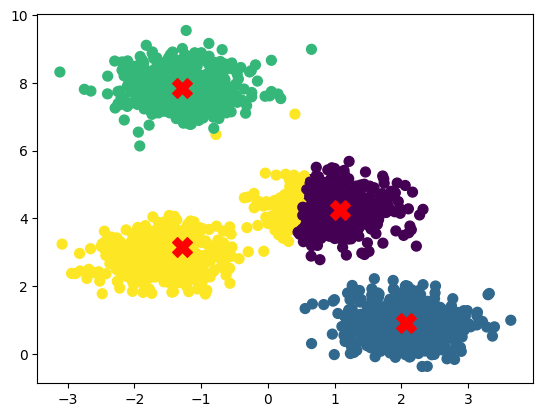

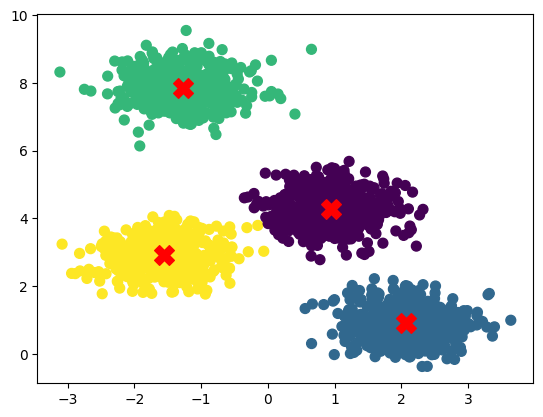

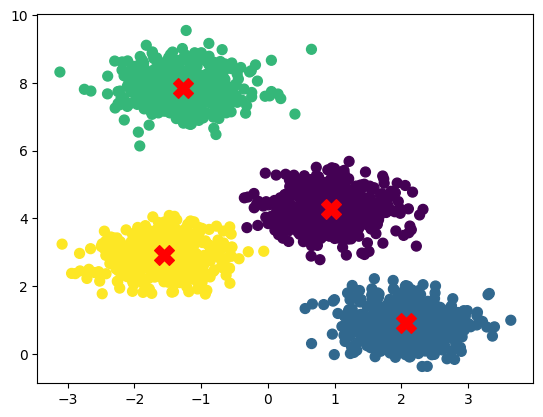

In [22]:
model = KMeans(n_clusters=4, max_iter=300, random_state=42)
model.fit(X)

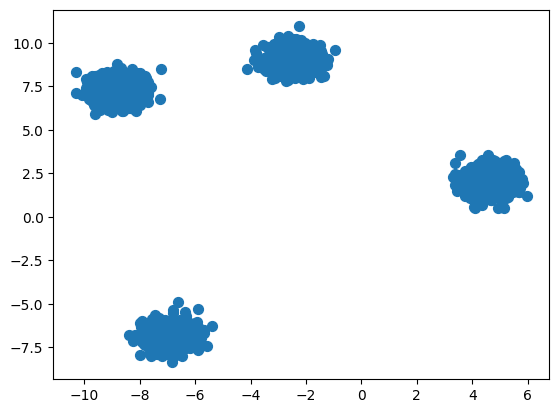

In [23]:
# Generate synthetic data
X, y =make_blobs(n_samples=2000, centers=4, n_features=2,random_state=42, cluster_std=0.5)
 #make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);
plt.show()

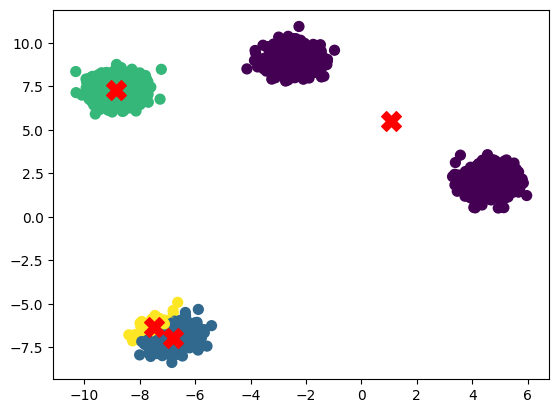

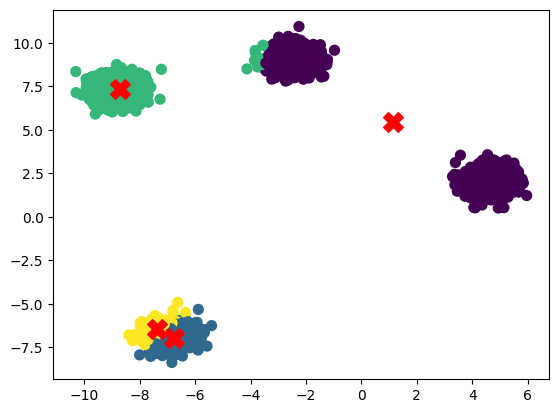

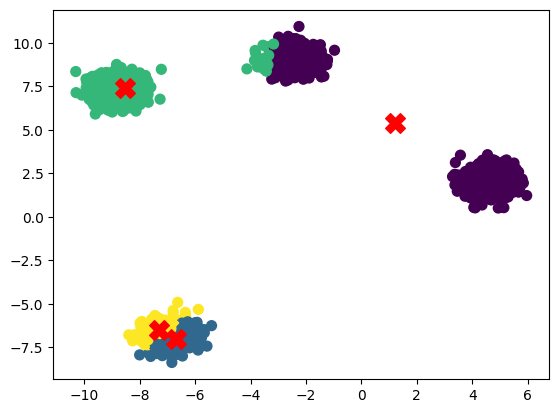

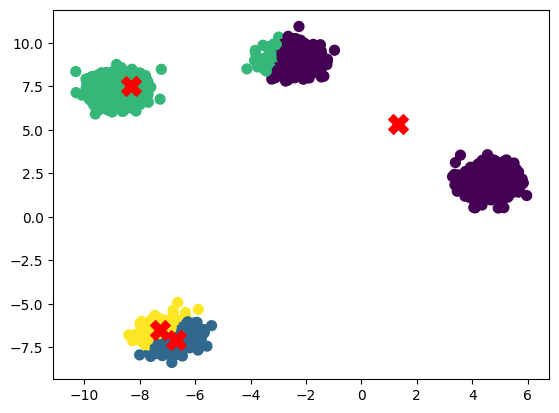

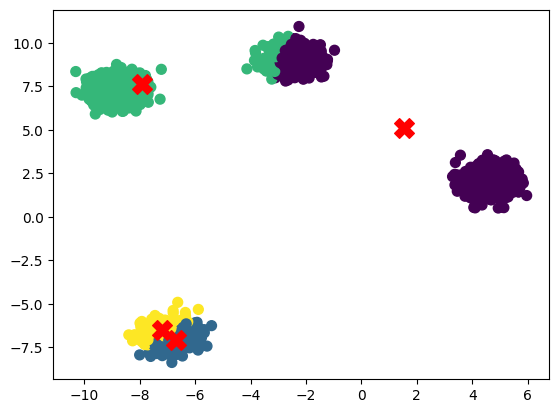

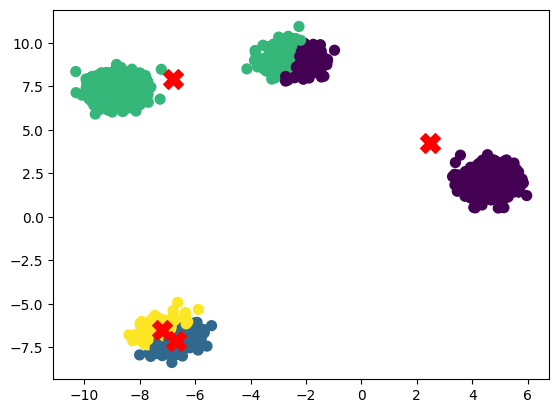

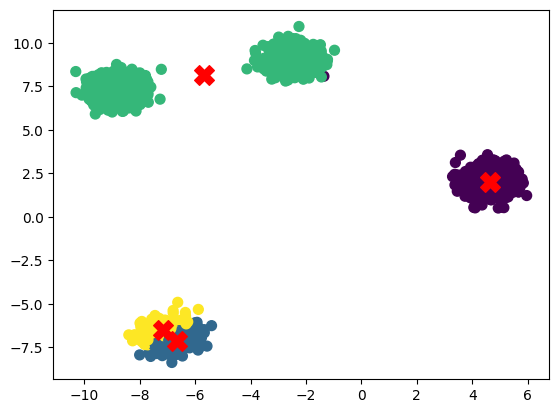

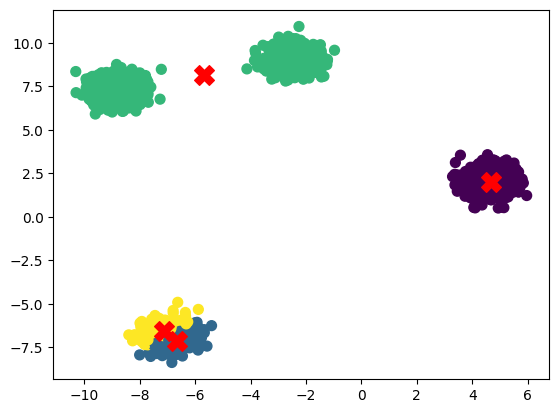

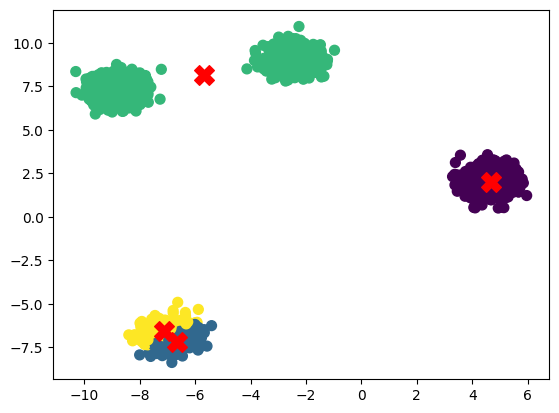

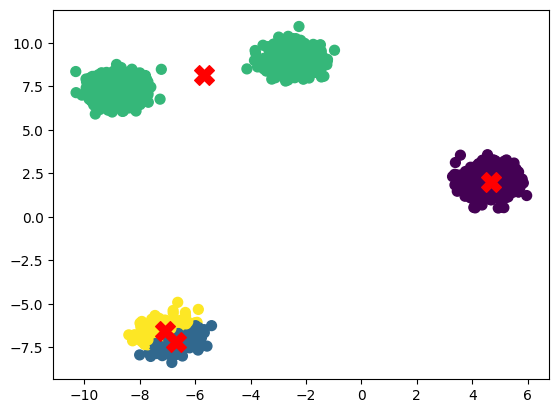

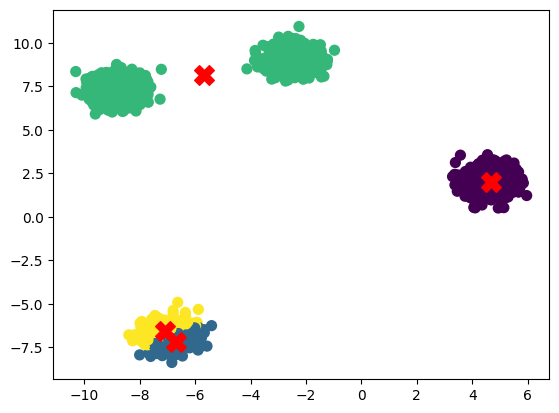

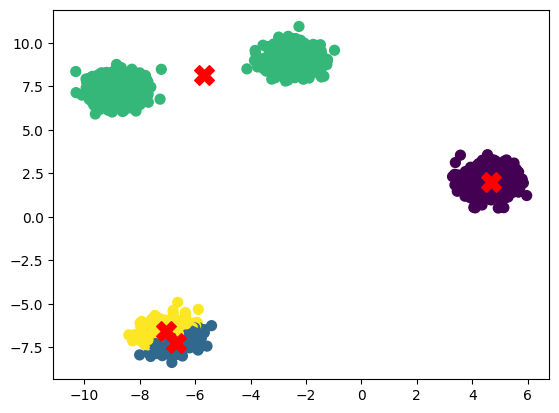

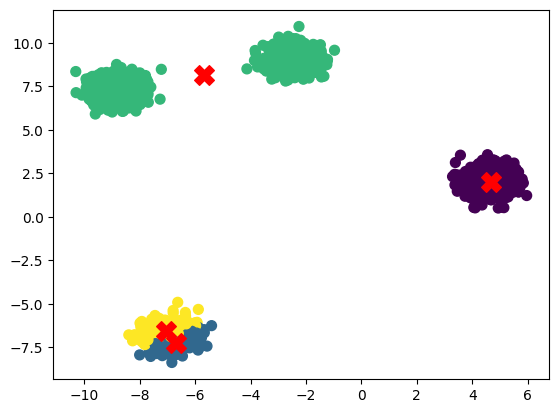

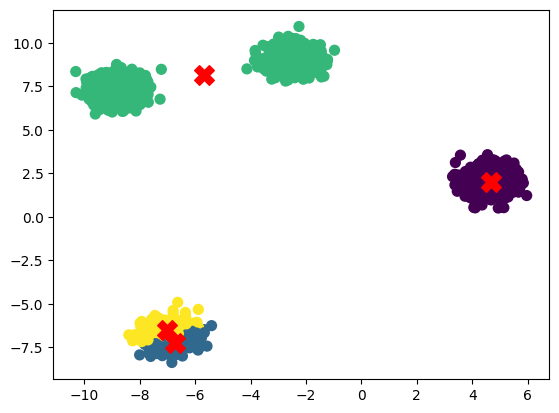

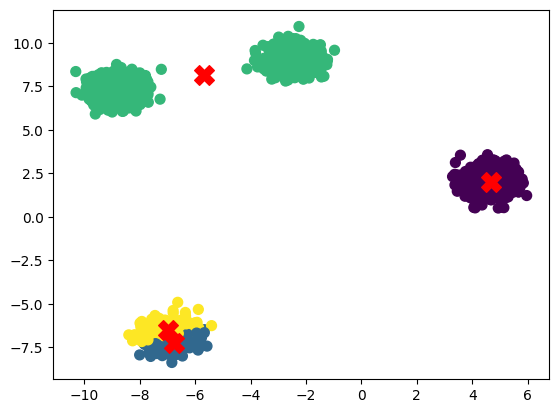

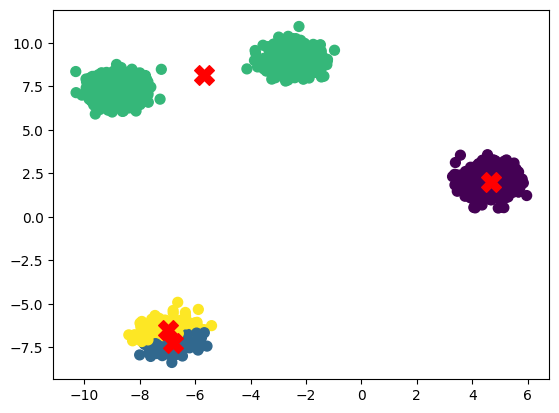

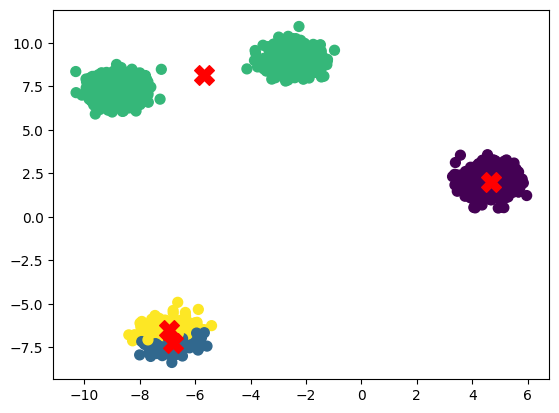

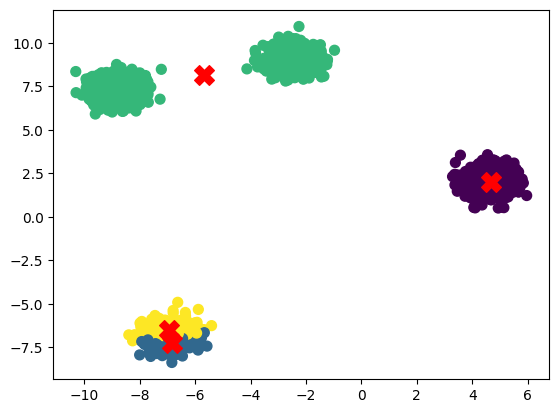

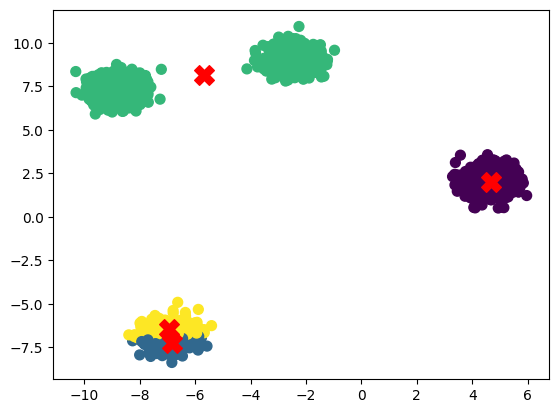

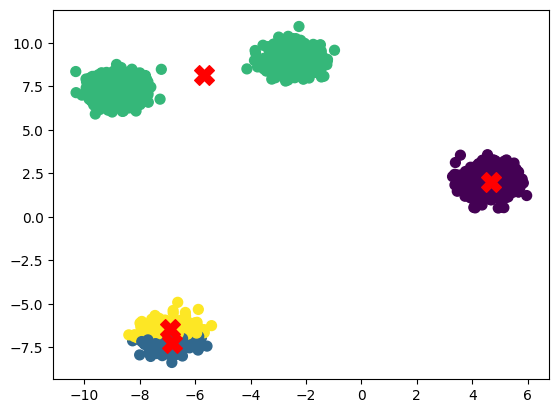

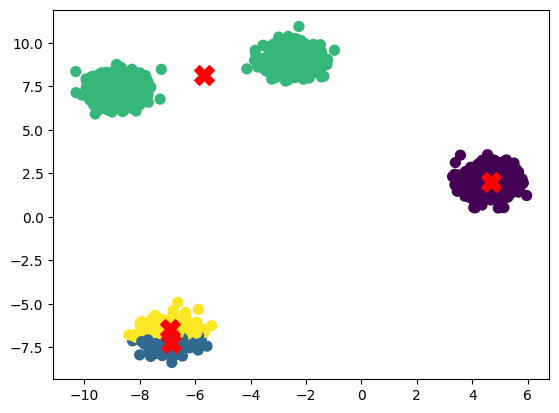

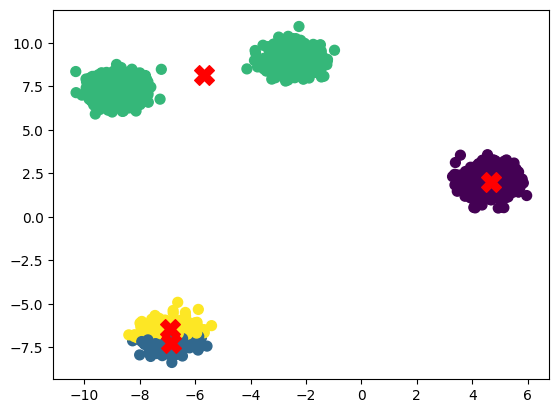

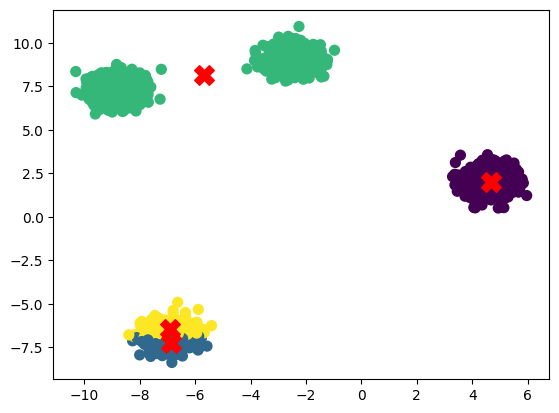

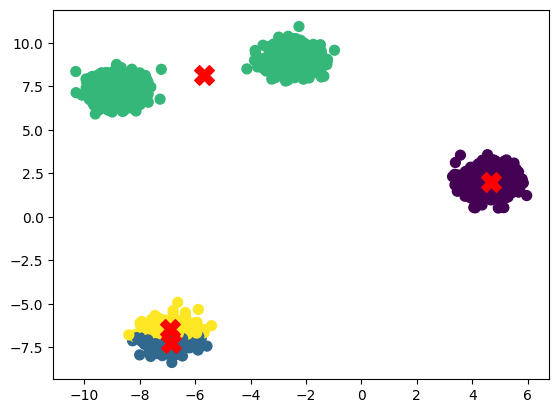

In [24]:
model = KMeans(n_clusters=4, max_iter=300, random_state=42)
model.fit(X)